In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import io as sio
import seaborn as sns 
from sklearn.preprocessing import LabelBinarizer , StandardScaler ,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , accuracy_score,ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression , RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from numpy import absolute
from numpy import sqrt
from numpy import mean
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import pandas as pd
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier , VotingClassifier , RandomForestClassifier

In [2]:
data = pd.read_csv("Heart Disease Dataset.csv")
data.head(10)

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [3]:
data.tail(10)

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
3380,0,48,1,5.0,0.0,0,0,0,262.0,141.0,88.0,25.21,80.0,NaN,0
3381,1,51,0,0.0,0.0,0,1,0,227.0,158.0,105.0,27.22,60.0,96.0,1
3382,0,61,0,0.0,0.0,0,1,0,254.0,168.0,92.0,31.63,80.0,90.0,0
3383,1,56,1,43.0,0.0,0,1,0,240.0,128.5,87.5,31.50,80.0,NaN,0
3384,1,41,0,0.0,0.0,0,0,0,245.0,139.0,84.0,28.76,95.0,68.0,0
3385,1,47,1,15.0,0.0,0,0,0,206.0,125.0,72.0,21.14,80.0,74.0,0
3386,0,50,1,25.0,0.0,0,0,0,330.0,119.0,86.0,26.30,86.0,NaN,0
3387,1,37,1,30.0,0.0,0,0,0,249.0,112.0,70.0,22.79,56.0,76.0,0
3388,1,59,1,20.0,0.0,0,0,0,163.0,138.0,80.0,31.08,70.0,70.0,0
3389,1,50,1,20.0,0.0,0,0,0,265.0,110.0,65.0,24.45,69.0,70.0,0


In [4]:
#Shape of Data
data.shape

(3390, 15)

In [5]:
data['HD'].value_counts()

0    2873
1     517
Name: HD, dtype: int64

In [6]:
#infromation of dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SX      3390 non-null   int64  
 1   AG      3390 non-null   int64  
 2   SM      3390 non-null   int64  
 3   CPD     3367 non-null   float64
 4   BPM     3346 non-null   float64
 5   PS      3390 non-null   int64  
 6   PH      3390 non-null   int64  
 7   DB      3390 non-null   int64  
 8   TC      3348 non-null   float64
 9   SBP     3390 non-null   float64
 10  DBP     3390 non-null   float64
 11  BMI     3371 non-null   float64
 12  HR      3389 non-null   float64
 13  GL      3072 non-null   float64
 14  HD      3390 non-null   int64  
dtypes: float64(8), int64(7)
memory usage: 397.4 KB


In [7]:
#lets describe the data
data.describe()

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
count,3390.000000,3390.000000,3390.000000,3367.000000,3346.000000,3390.000000,3390.000000,3390.000000,3348.000000,3390.000000,3390.000000,3371.000000,3389.000000,3072.000000,3390.000000
mean,0.425369,49.564602,0.494395,8.974458,0.028691,0.005015,0.305015,0.023009,237.256272,132.183038,82.889086,25.815823,75.623488,81.667318,0.152507
std,0.494472,8.568013,0.500042,11.870111,0.166961,0.070648,0.460482,0.149954,44.830218,21.868974,11.765666,4.067961,11.971946,22.111393,0.359565
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,50.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.090000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.380000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,264.000000,143.000000,90.000000,28.090000,82.000000,87.000000,0.000000
max,1.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [8]:
data.count()

SX     3390
AG     3390
SM     3390
CPD    3367
BPM    3346
PS     3390
PH     3390
DB     3390
TC     3348
SBP    3390
DBP    3390
BMI    3371
HR     3389
GL     3072
HD     3390
dtype: int64

In [9]:
label_encoder = preprocessing.LabelEncoder()
data['SX']= label_encoder.fit_transform(data['SX'])
  
data['SX'].unique()

array([1, 0], dtype=int64)

In [10]:
data.head(2)

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0


In [11]:
label_encoder = preprocessing.LabelEncoder()
data['SM']= label_encoder.fit_transform(data['SM'])
  
data['SM'].unique()

array([0, 1], dtype=int64)

In [12]:
data.head(2)

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0


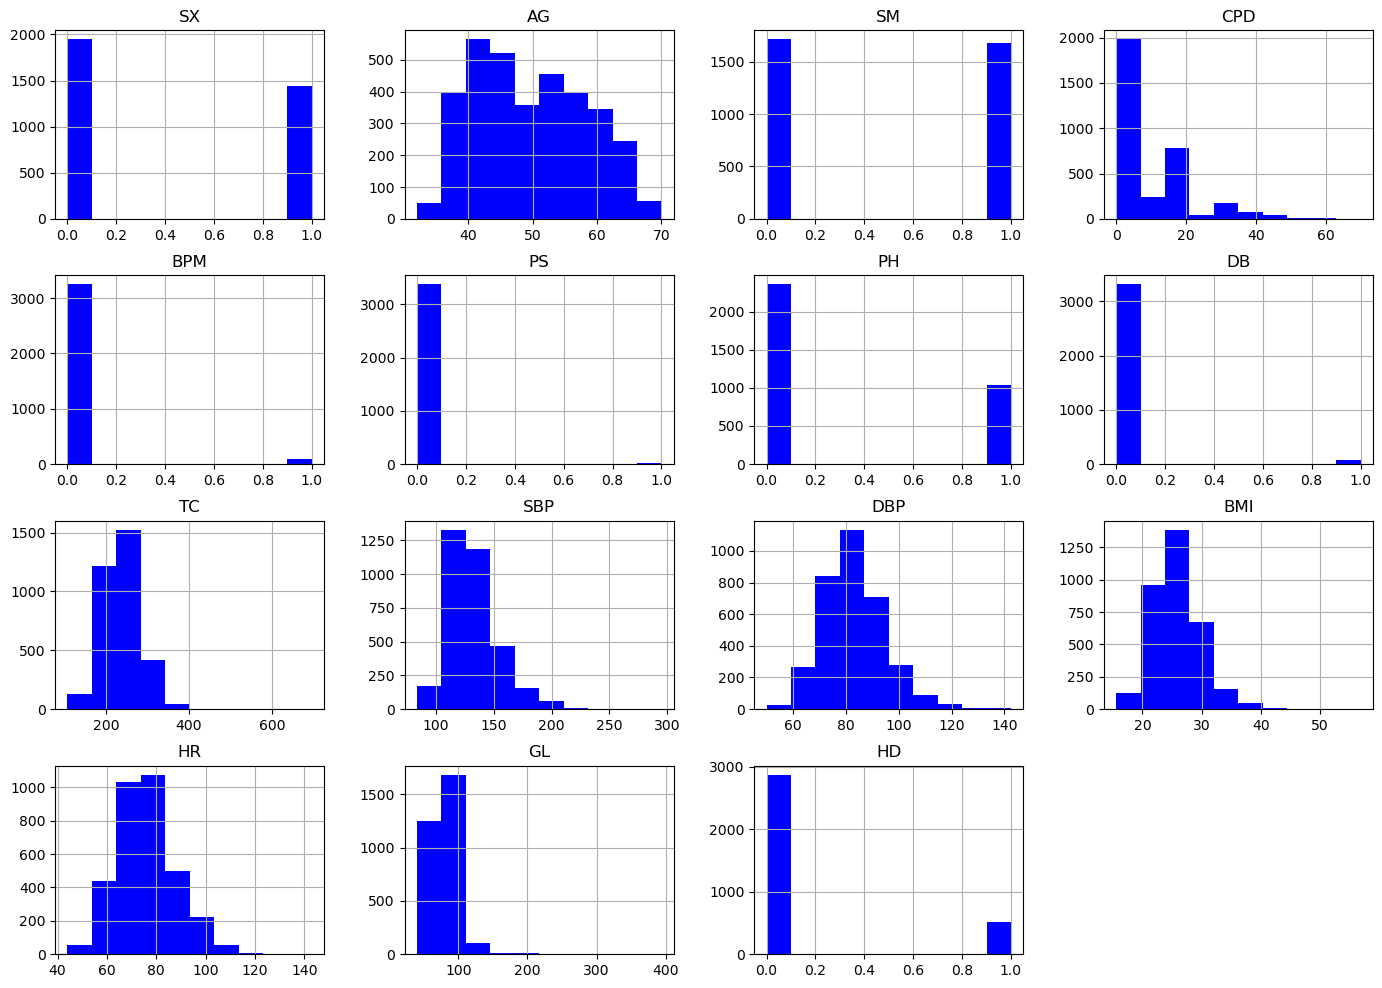

In [13]:
#histogram
data.hist(color='Blue',bins=10,figsize=(17,12))
plt.show()

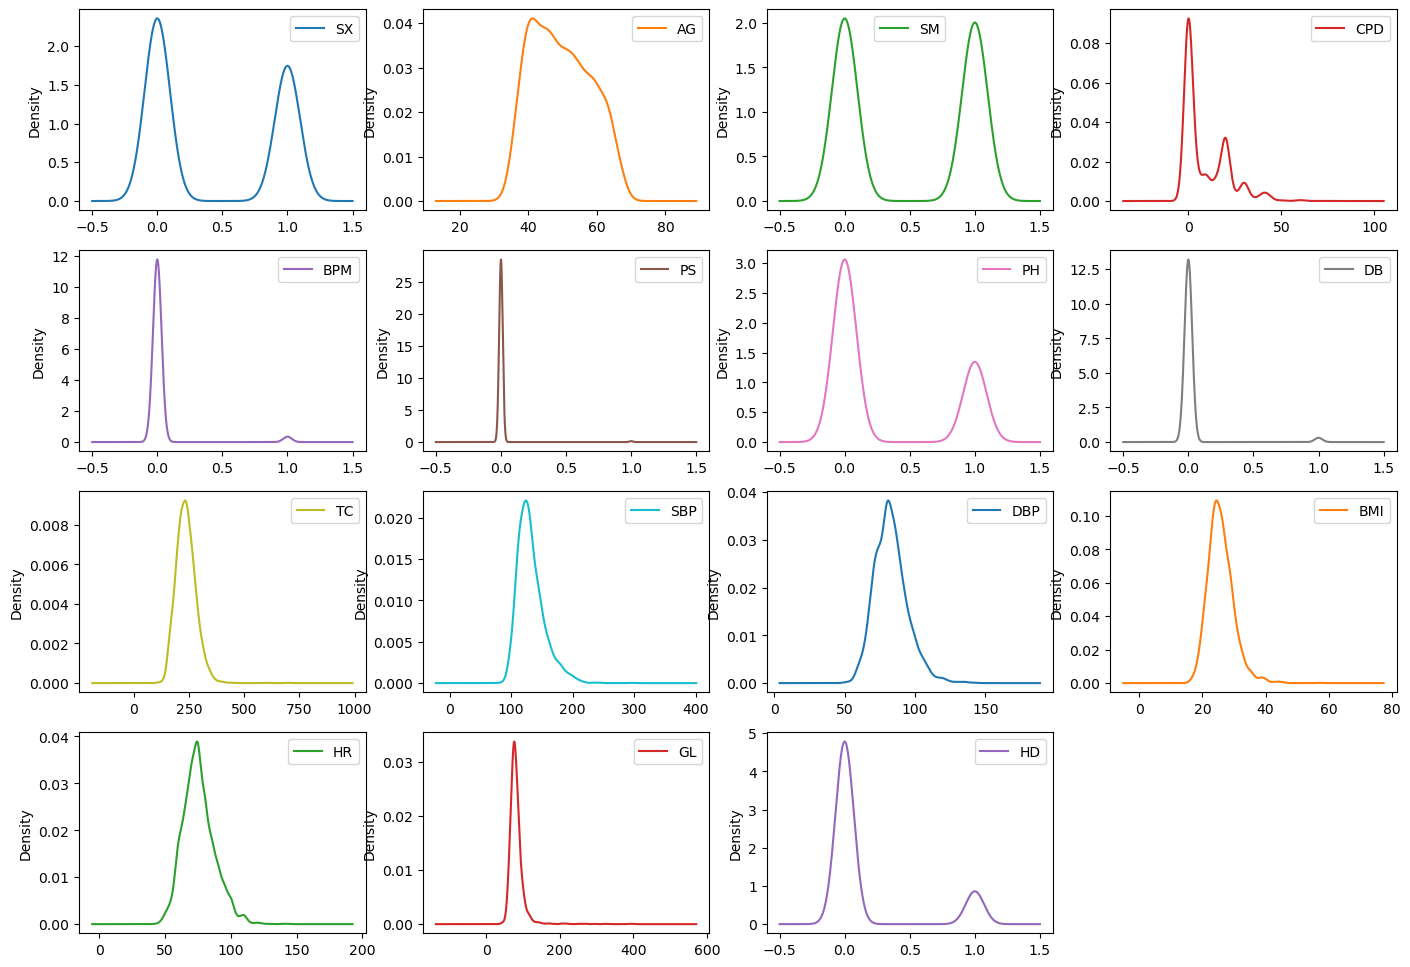

In [14]:
#Boxplot of each column
data.plot( kind='density', figsize=(17,12), subplots=True, layout=(4,4),sharex=False)
plt.show()

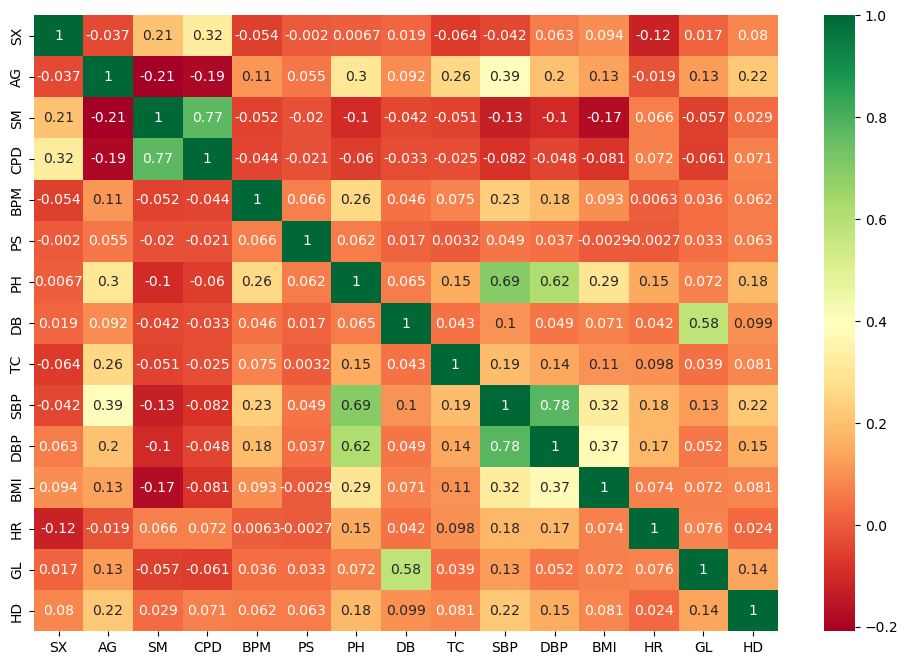

In [15]:
#get correlations of each features in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(12,8))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [16]:
import plotly.graph_objects as go

In [17]:
column_names = data.columns
no_of_boxes = len(column_names)
colors = [ 'hsl(' + str(h) + ',50%' + ',50%)' for h in np.linspace(0, 360, no_of_boxes)]

fig = go.Figure(data = [go.Box(y = data.loc[:, column_names[i]], marker_color = colors[i], name = column_names[i], boxmean = True, showlegend = True) for i in range(no_of_boxes)])

fig.update_layout(
    xaxis=dict(showgrid = True, zeroline = True, showticklabels = True),
    yaxis=dict(zeroline = True, gridcolor = 'white'),
    paper_bgcolor = 'rgb(233,233,233)',
    plot_bgcolor = 'rgb(233,233,233)')

fig.show()

<Axes: >

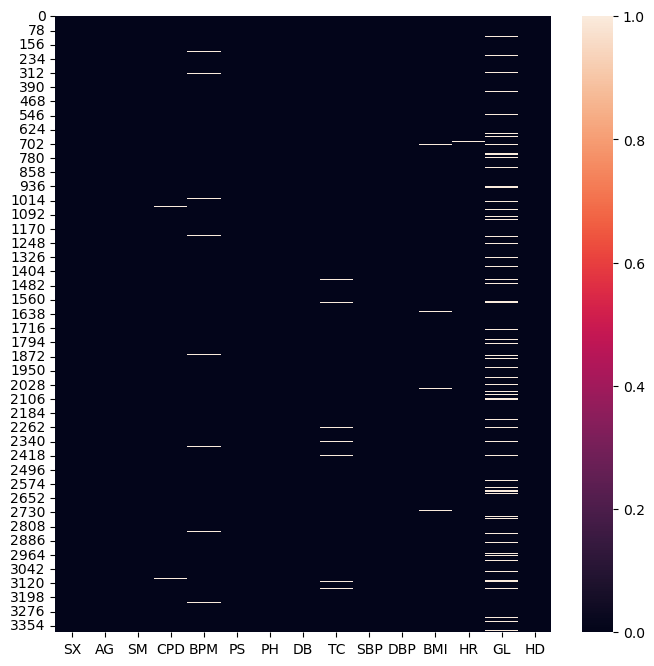

In [18]:
plt.figure(figsize=(8,8))
sns.heatmap(data.isnull())

In [19]:
data['CPD'].fillna(int(data['CPD'].mean()), inplace=True)

In [20]:
data['BPM'].fillna(int(data['BPM'].mean()), inplace=True)

In [21]:
data['TC'].fillna(int(data['TC'].mean()), inplace=True)

In [22]:
data['BMI'].fillna(int(data['BMI'].mean()), inplace=True)

In [23]:
data['HR'].fillna(int(data['HR'].mean()), inplace=True)

In [24]:
data['GL'].fillna(int(data['GL'].mean()), inplace=True)

<Axes: >

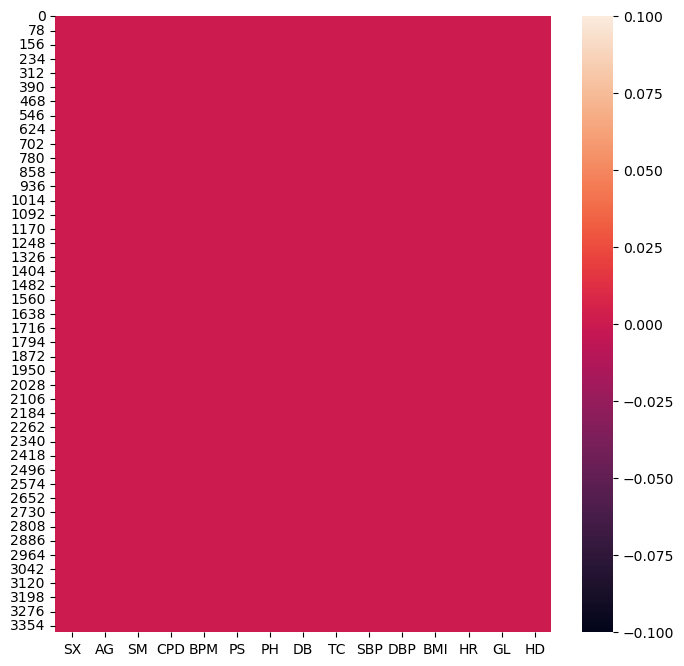

In [25]:
plt.figure(figsize=(8,8))
sns.heatmap(data.isnull())

In [26]:
data.head(10)

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
6,0,63,0,0.0,0.0,0,0,0,205.0,138.0,71.0,33.11,60.0,85.0,1
7,0,45,1,20.0,0.0,0,0,0,313.0,100.0,71.0,21.68,79.0,78.0,0
8,1,52,0,0.0,0.0,0,1,0,260.0,141.5,89.0,26.36,76.0,79.0,0
9,1,43,1,30.0,0.0,0,1,0,225.0,162.0,107.0,23.61,93.0,88.0,0


In [27]:
#checking for the out layers with STD
print("Highest allowed",data['TC'].mean() + 3*data['TC'].std())
print("Lowest allowed",data['TC'].mean() - 3*data['TC'].std())

Highest allowed 370.9078071919522
Lowest allowed 103.59838749831329


In [28]:
#dealing with out layer values 
data[(data['TC'] > 350) | (data['TC'] < 110)]


,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
194,0,42,0,0.0,0.0,0,0,0,464.0,128.0,87.0,22.90,72.0,72.0,1
259,0,60,0,0.0,0.0,0,1,0,352.0,197.5,105.0,36.29,75.0,95.0,1
333,0,55,0,0.0,1.0,0,1,0,368.0,204.0,94.0,25.20,100.0,81.0,0
533,0,53,0,0.0,0.0,0,0,0,370.0,123.0,83.0,24.64,63.0,74.0,1
543,1,47,1,18.0,0.0,0,1,0,439.0,145.0,74.0,22.42,100.0,90.0,1
617,0,51,1,3.0,0.0,0,1,0,398.0,161.0,96.0,23.63,77.0,83.0,0
670,0,65,0,0.0,0.0,0,0,0,355.0,138.0,79.0,28.38,75.0,108.0,0
920,0,60,1,15.0,0.0,0,0,0,353.0,116.0,82.0,22.66,85.0,71.0,0
926,1,61,1,20.0,0.0,0,1,0,360.0,157.0,99.0,28.74,95.0,73.0,0
998,0,57,0,0.0,0.0,0,0,0,372.0,122.0,80.0,21.02,65.0,81.0,0


In [29]:
new_df = data[(data['TC'] <350) & (data['TC'] >110)]
new_df

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,1,47,1,15.0,0.0,0,0,0,206.0,125.0,72.0,21.14,80.0,74.0,0
3386,0,50,1,25.0,0.0,0,0,0,330.0,119.0,86.0,26.30,86.0,81.0,0
3387,1,37,1,30.0,0.0,0,0,0,249.0,112.0,70.0,22.79,56.0,76.0,0
3388,1,59,1,20.0,0.0,0,0,0,163.0,138.0,80.0,31.08,70.0,70.0,0


In [30]:
#storing the values 
upper_limit = data['TC'].mean() + 3*data['TC'].std()
lower_limit = data['TC'].mean() - 3*data['TC'].std()

In [31]:
data['TC'] = np.where(
    data['TC']>upper_limit,
    upper_limit,
    np.where(
        data['TC']<lower_limit,
        lower_limit,
        data['TC']
    )
)

In [32]:
data['TC'].describe()

count    3390.000000
mean      236.952903
std        43.020900
min       107.000000
25%       207.000000
50%       235.000000
75%       264.000000
max       370.907807
Name: TC, dtype: float64

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\4092499604.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\4092499604.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




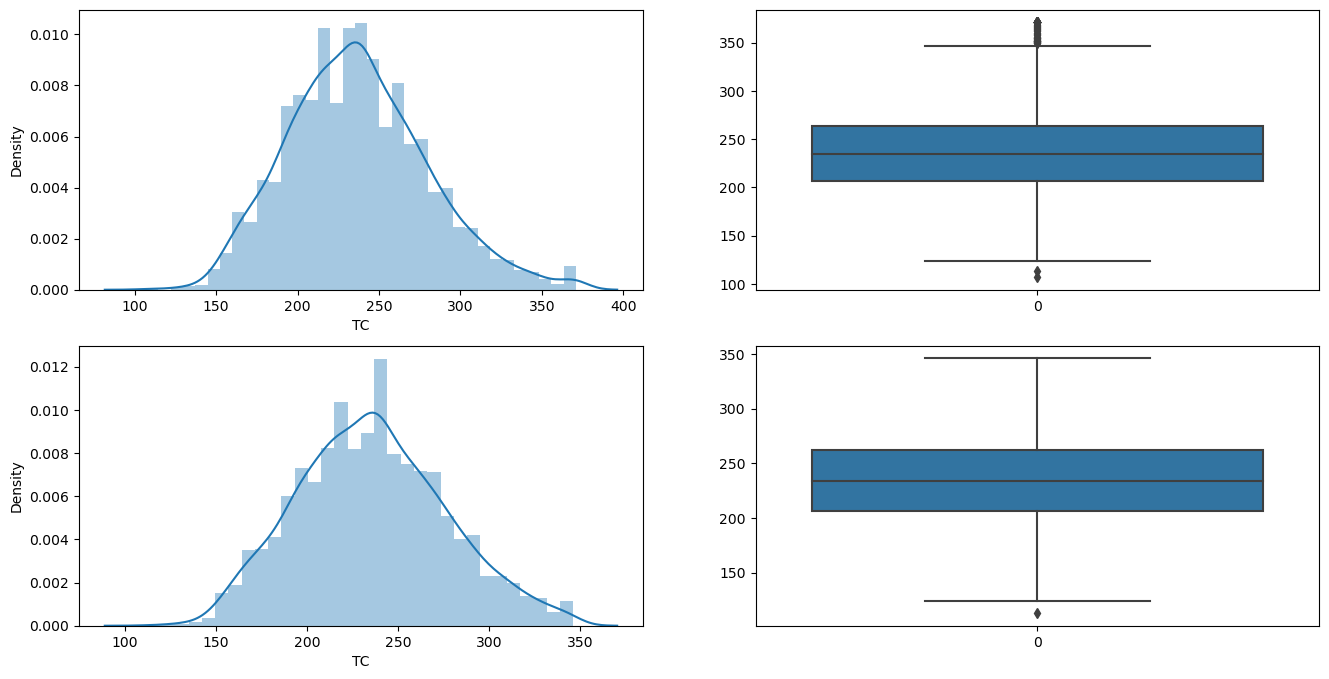

In [33]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['TC'])
plt.subplot(2,2,2)
sns.boxplot(data['TC'])
plt.subplot(2,2,3)
sns.distplot(new_df['TC'])
plt.subplot(2,2,4)
sns.boxplot(new_df['TC'])
plt.show()

In [34]:
#checking for the out layers with STD
print("Highest allowed",data['GL'].mean() + 3*data['GL'].std())
print("Lowest allowed",data['GL'].mean() - 3*data['GL'].std())

Highest allowed 144.75278428405315
Lowest allowed 18.45665524397046


In [35]:
#dealing with out layer values 
data[(data['GL'] > 100) | (data['GL'] < 55)]

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
22,0,52,0,0.0,0.0,0,0,0,234.0,148.0,78.0,34.17,70.0,113.0,0
37,1,52,0,0.0,0.0,0,1,1,178.0,160.0,98.0,40.11,75.0,225.0,0
44,0,53,0,0.0,1.0,0,1,1,311.0,206.0,92.0,21.51,76.0,215.0,1
65,0,63,0,0.0,0.0,0,1,0,252.0,154.0,87.0,28.60,72.0,45.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3327,1,44,1,25.0,0.0,0,0,1,241.0,111.0,78.0,27.78,85.0,167.0,1
3331,0,39,0,0.0,0.0,0,0,0,186.0,124.0,80.0,29.70,75.0,102.0,0
3333,0,40,1,3.0,0.0,0,0,0,173.0,125.0,75.0,25.67,65.0,102.0,0
3336,0,50,0,0.0,0.0,0,0,0,240.0,107.5,70.0,26.76,67.0,102.0,0


In [36]:
new_df = data[(data['GL'] <100) & (data['GL'] >55)]
new_df

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
5,0,43,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,1,47,1,15.0,0.0,0,0,0,206.0,125.0,72.0,21.14,80.0,74.0,0
3386,0,50,1,25.0,0.0,0,0,0,330.0,119.0,86.0,26.30,86.0,81.0,0
3387,1,37,1,30.0,0.0,0,0,0,249.0,112.0,70.0,22.79,56.0,76.0,0
3388,1,59,1,20.0,0.0,0,0,0,163.0,138.0,80.0,31.08,70.0,70.0,0


In [37]:
#storing the values 
upper_limit = data['GL'].mean() + 3*data['GL'].std()
lower_limit = data['GL'].mean() - 3*data['GL'].std()

In [38]:
data['GL'] = np.where(
    data['GL']>upper_limit,
    upper_limit,
    np.where(
        data['GL']<lower_limit,
        lower_limit,
        data['GL']
    )
)

In [39]:
data['GL'].describe()

count    3390.000000
mean       80.725475
std        14.384467
min        40.000000
25%        72.000000
50%        80.000000
75%        85.000000
max       144.752784
Name: GL, dtype: float64

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\2732704994.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\2732704994.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




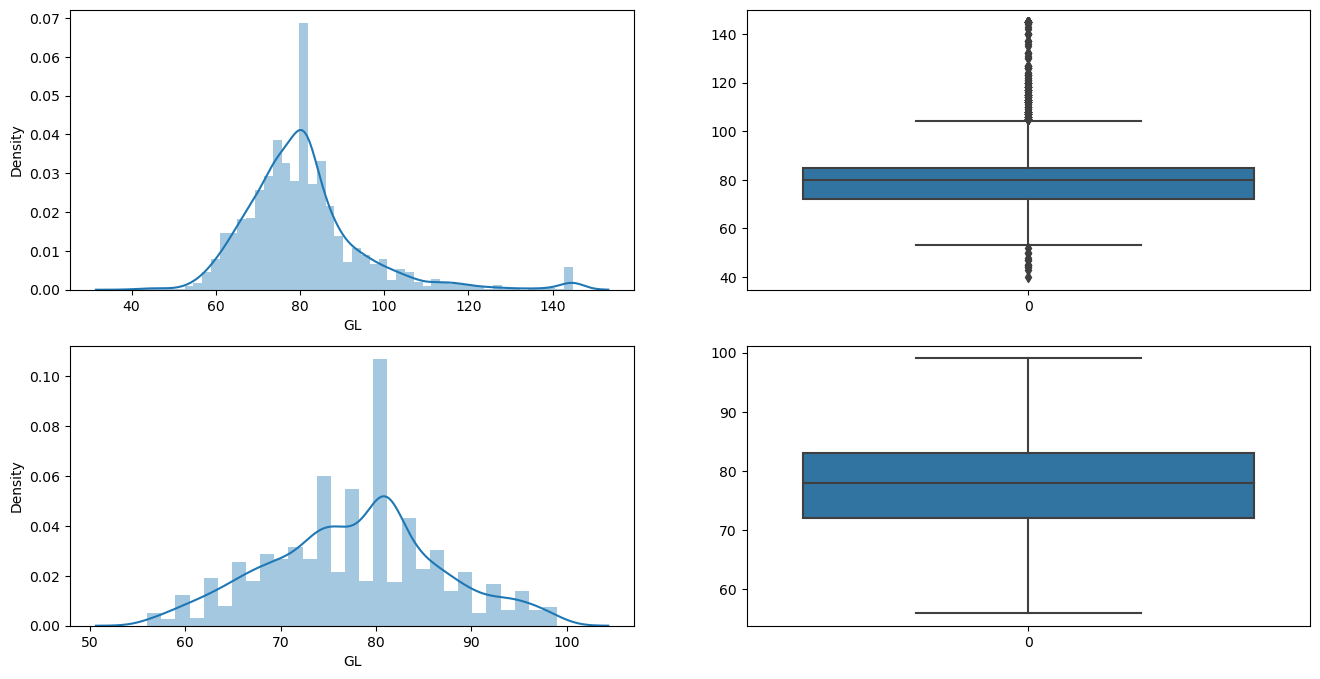

In [40]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['GL'])
plt.subplot(2,2,2)
sns.boxplot(data['GL'])
plt.subplot(2,2,3)
sns.distplot(new_df['GL'])
plt.subplot(2,2,4)
sns.boxplot(new_df['GL'])
plt.show()

<Axes: >

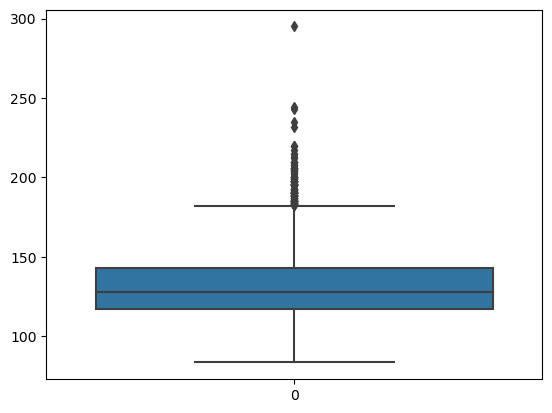

In [41]:
# Box Plot
import seaborn as sns
sns.boxplot(data['SBP'])

In [42]:
#dealing with out layer values 
data[(data['SBP'] > 175) | (data['SBP'] < 90)]

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
5,0,43,0,0.0,0.0,0,1,0,228.0,180.0,110.0,30.30,77.0,99.000000,0
28,0,61,0,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.000000,1
44,0,53,0,0.0,1.0,0,1,1,311.0,206.0,92.0,21.51,76.0,144.752784,1
46,0,65,0,0.0,0.0,0,1,0,252.0,179.5,114.0,30.47,90.0,87.000000,0
66,0,62,0,0.0,0.0,0,1,1,212.0,190.0,99.0,29.64,100.0,144.752784,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3214,0,57,0,0.0,0.0,0,0,0,194.0,199.5,107.0,26.84,60.0,69.000000,1
3233,0,66,0,0.0,0.0,0,1,0,263.0,193.0,95.0,27.07,115.0,94.000000,1
3320,0,52,0,0.0,1.0,0,1,0,264.0,181.0,112.5,24.80,74.0,77.000000,1
3322,1,57,1,3.0,0.0,0,1,0,225.0,177.5,120.0,25.48,72.0,96.000000,1


In [43]:
new_df = data[(data['SBP'] <175) & (data['SBP'] >90)]
new_df

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,1,47,1,15.0,0.0,0,0,0,206.0,125.0,72.0,21.14,80.0,74.0,0
3386,0,50,1,25.0,0.0,0,0,0,330.0,119.0,86.0,26.30,86.0,81.0,0
3387,1,37,1,30.0,0.0,0,0,0,249.0,112.0,70.0,22.79,56.0,76.0,0
3388,1,59,1,20.0,0.0,0,0,0,163.0,138.0,80.0,31.08,70.0,70.0,0


In [44]:
#storing the values 
upper_limit = data['SBP'].mean() + 3*data['SBP'].std()
lower_limit = data['SBP'].mean() - 3*data['SBP'].std()

In [45]:
data['SBP'] = np.where(
    data['SBP']>upper_limit,
    upper_limit,
    np.where(
        data['SBP']<lower_limit,
        lower_limit,
        data['SBP']
    )
)

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\3991105116.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\3991105116.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




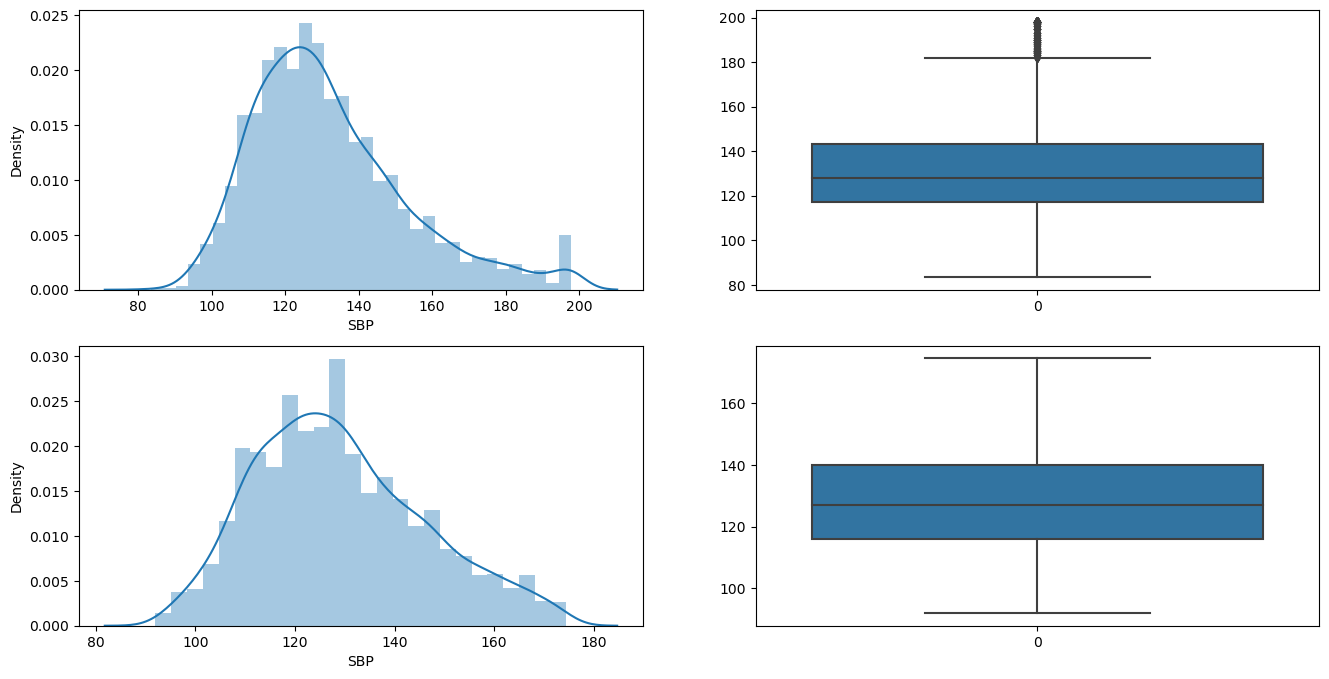

In [46]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['SBP'])
plt.subplot(2,2,2)
sns.boxplot(data['SBP'])
plt.subplot(2,2,3)
sns.distplot(new_df['SBP'])
plt.subplot(2,2,4)
sns.boxplot(new_df['SBP'])
plt.show()

In [47]:
#checking for the out layers with STD
print("Highest allowed",data['HR'].mean() + 3*data['HR'].std())
print("Lowest allowed",data['HR'].mean() - 3*data['HR'].std())

Highest allowed 111.53385806715008
Lowest allowed 39.71274960246643


In [48]:
#dealing with out layer values 
data[(data['HR'] > 103) | (data['HR'] < 40.85555922142802)]

,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
162,0,47,0,0.0,0.0,0,0,0,174.0,118.0,86.5,26.15,110.0,86.0,0
216,0,43,0,0.0,0.0,0,0,0,263.0,115.0,82.5,25.91,105.0,81.0,0
270,0,54,0,0.0,0.0,0,1,0,273.0,139.0,98.0,29.06,110.0,73.0,1
339,0,64,0,0.0,0.0,0,1,0,312.0,160.0,82.0,27.59,140.0,94.0,0
358,0,40,1,20.0,0.0,0,0,0,210.0,118.0,79.0,21.21,130.0,84.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3225,0,50,0,0.0,0.0,0,1,0,236.0,152.0,92.0,24.47,120.0,67.0,1
3231,0,46,1,6.0,0.0,0,1,0,315.0,165.0,85.0,32.89,110.0,91.0,0
3233,0,66,0,0.0,0.0,0,1,0,263.0,193.0,95.0,27.07,115.0,94.0,1
3242,1,52,1,35.0,0.0,0,1,1,281.0,133.0,93.0,32.27,115.0,80.0,0


In [49]:
new_df = data[(data['HR'] < 103) & (data['HR'] >40.85555922142802)]
new_df


,SX,AG,SM,CPD,BPM,PS,PH,DB,TC,SBP,DBP,BMI,HR,GL,HD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,1,47,1,15.0,0.0,0,0,0,206.0,125.0,72.0,21.14,80.0,74.0,0
3386,0,50,1,25.0,0.0,0,0,0,330.0,119.0,86.0,26.30,86.0,81.0,0
3387,1,37,1,30.0,0.0,0,0,0,249.0,112.0,70.0,22.79,56.0,76.0,0
3388,1,59,1,20.0,0.0,0,0,0,163.0,138.0,80.0,31.08,70.0,70.0,0


In [50]:
#storing the values 
upper_limit = data['HR'].mean() + 3*data['HR'].std()
lower_limit = data['HR'].mean() - 3*data['HR'].std()

In [51]:
data['HR'] = np.where(
    data['HR']>upper_limit,
    upper_limit,
    np.where(
        data['HR']<lower_limit,
        lower_limit,
        data['HR']
    )
)

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\125774344.py:4: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_13752\125774344.py:8: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




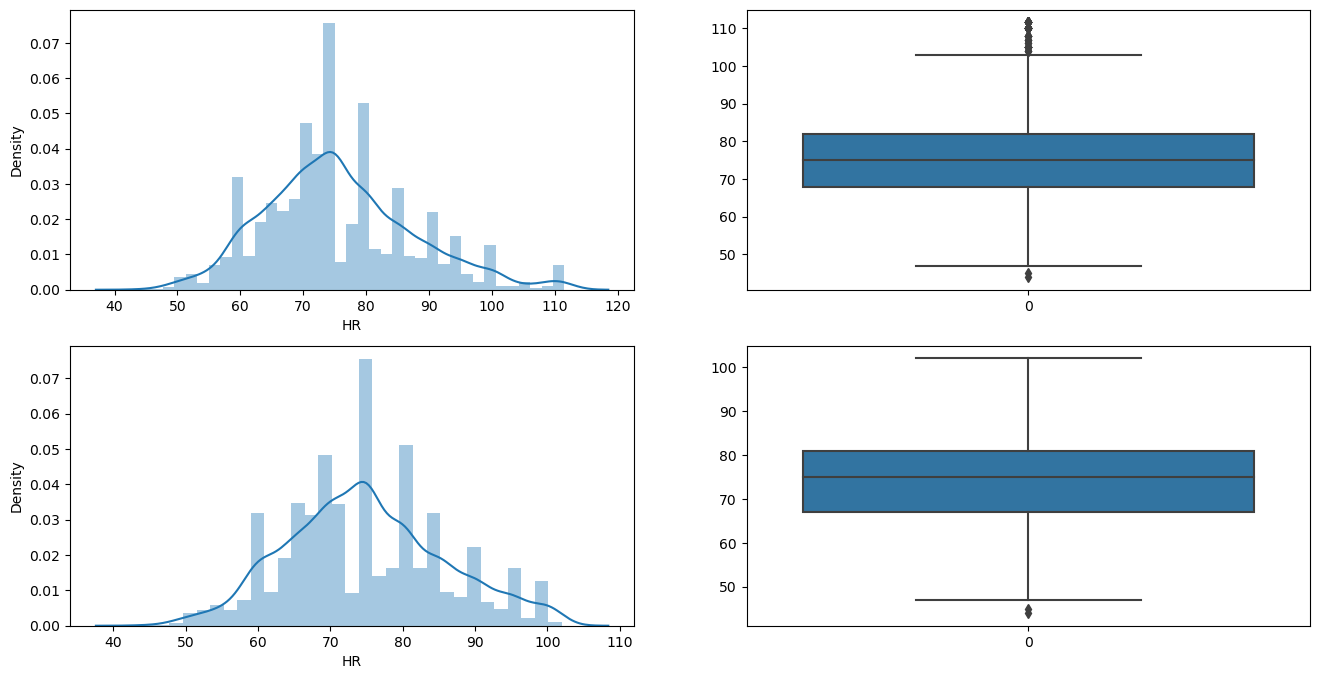

In [52]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['HR'])
plt.subplot(2,2,2)
sns.boxplot(data['HR'])
plt.subplot(2,2,3)
sns.distplot(new_df['HR'])
plt.subplot(2,2,4)
sns.boxplot(new_df['HR'])
plt.show()

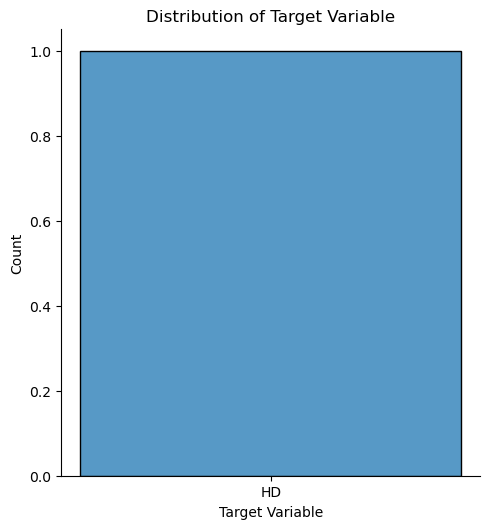

In [53]:
import seaborn as sns

# Sample target variable data
target_variable = ['HD']

# Plot the distribution
sns.displot(target_variable, kde=False)
plt.title('Distribution of Target Variable')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()


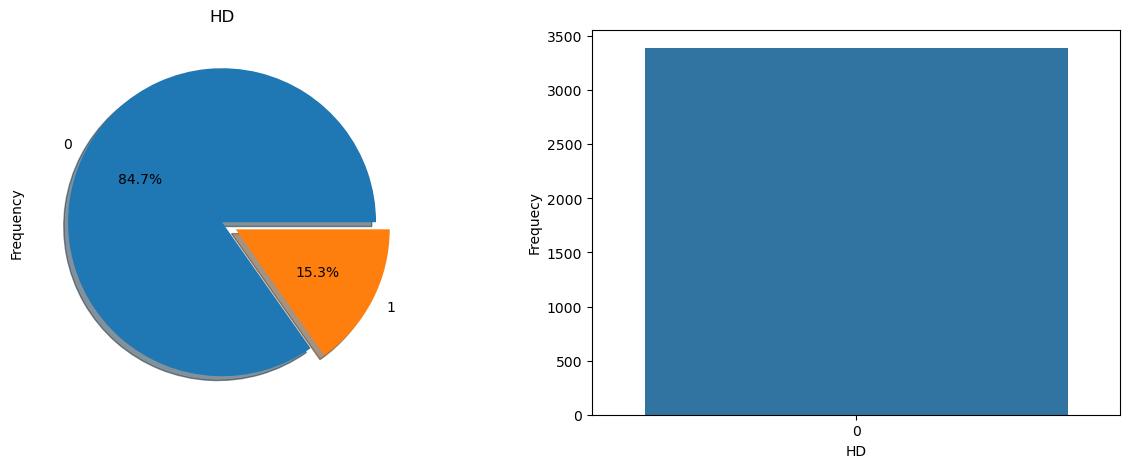

In [54]:
#Plot the diabetic Values
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(data['HD'])
#plt.title("Frequency of Heart Disease in Dataset")
plt.xlabel("HD")
plt.ylabel("Frequecy")

#Piechart show
data['HD'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('HD')
ax[0].set_ylabel('Frequency')
plt.show()

In [55]:
data_boxcox = data.copy()
X = data_boxcox.drop(["HD"],axis=1)
Y = data_boxcox["HD"]

In [56]:
#To keep BoxCox data as it is to use the same for later.
data_bal = data_boxcox.copy()

#Getting seperated data with 1 and 0 status.
df_majority = data_bal[data_bal.HD==0]
df_minority = data_bal[data_bal.HD==1]

#Here we are downsampling the Majority Class Data Points. 
#i.e. We will get equal amount of datapoint as Minority class from Majority class

df_manjority_downsampled = resample(df_majority,replace=False,n_samples=268,random_state=123)
df_downsampled = pd.concat([df_manjority_downsampled,df_minority])
print("Downsampled data:->\n",df_downsampled.HD.value_counts())

#Here we are upsampling the Minority Class Data Points. 
#i.e. We will get equal amount of datapoint as Majority class from Minority class
df_monority_upsampled = resample(df_minority,replace=True,n_samples=2000,random_state=123)
df_upsampled = pd.concat([df_majority,df_monority_upsampled])
print("Upsampled data:->\n",df_upsampled.HD.value_counts())

Downsampled data:->
 1    517
0    268
Name: HD, dtype: int64
Upsampled data:->
 0    2873
1    2000
Name: HD, dtype: int64


Text(0.5, 0, 'Outcome')

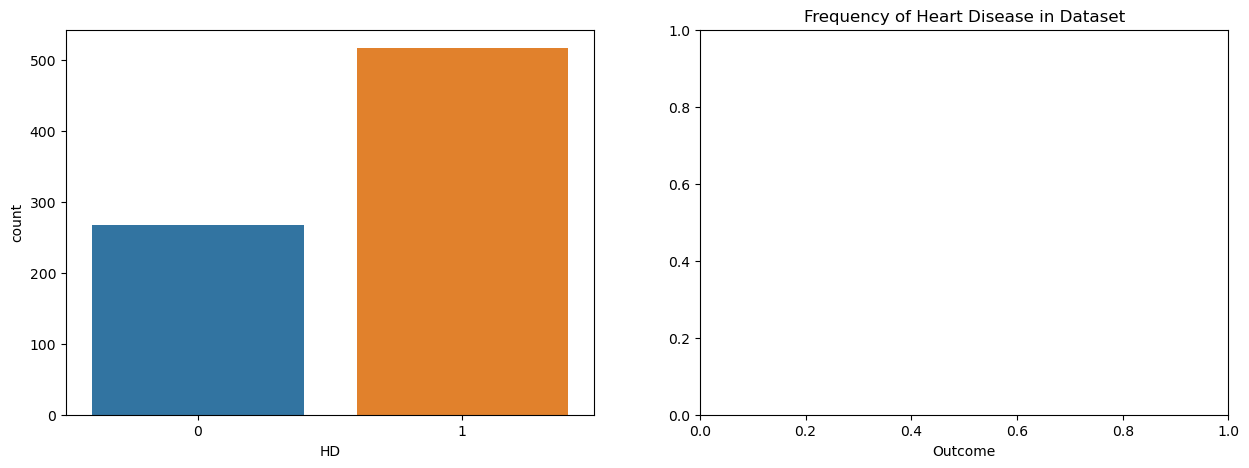

In [57]:
#Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_downsampled['TenYearCHD'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel("Outcome")
# plt.ylabel("Frequecy")
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='HD', data=df_downsampled, ax=ax[0])
plt.title("Frequency of Heart Disease in Dataset")
plt.xlabel("Outcome")

#Piechart show
# df_downsampled['TenYearCHD'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('TenYearCHD')
# ax[0].set_ylabel('Frequency')
# plt.show()

Text(0.5, 0, 'Outcome')

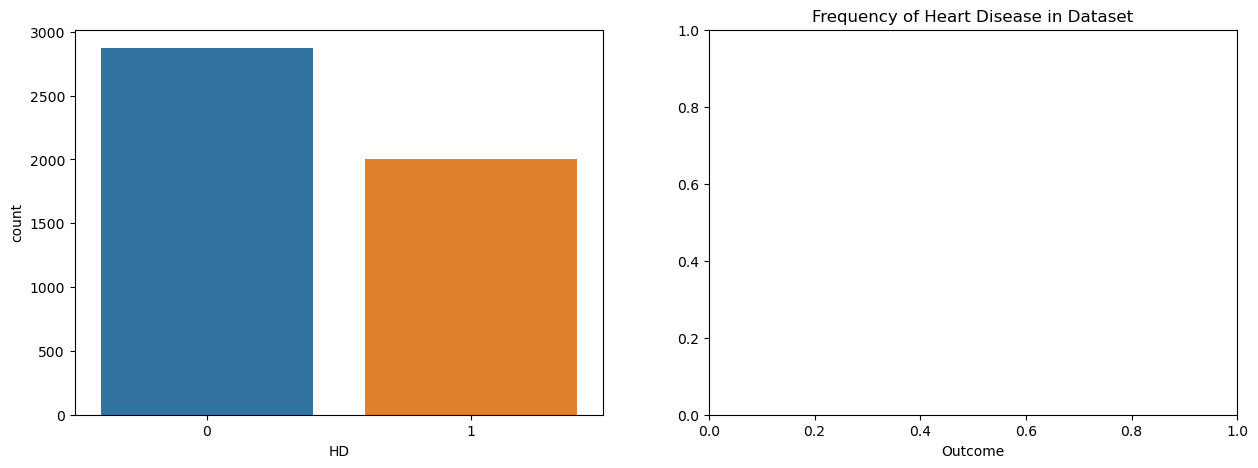

In [58]:
#Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_upsampled['TenYearCHD'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel("Outcome")
# plt.ylabel("Frequecy")
# #Piechart show
# df_upsampled['TenYearCHD'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('TenYearCHD')
# ax[0].set_ylabel('Frequency')
# plt.show()
#Plot the diabetic Values
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='HD', data=df_upsampled, ax=ax[0])
plt.title("Frequency of Heart Disease in Dataset")
plt.xlabel("Outcome")

In [59]:
#lets describe the data
df_upsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
SX,4873.0,0.457418,0.498235,0.00,0.00,0.00,1.00,1.000000
AG,4873.0,50.980915,8.673365,32.00,44.00,51.00,58.00,70.000000
SM,4873.0,0.506875,0.500004,0.00,0.00,1.00,1.00,1.000000
CPD,4873.0,9.711882,12.236060,0.00,0.00,1.00,20.00,70.000000
BPM,4873.0,0.035297,0.184547,0.00,0.00,0.00,0.00,1.000000
PS,4873.0,0.009235,0.095662,0.00,0.00,0.00,0.00,1.000000
PH,4873.0,0.369588,0.482743,0.00,0.00,0.00,1.00,1.000000
DB,4873.0,0.034270,0.181942,0.00,0.00,0.00,0.00,1.000000
TC,4873.0,239.516902,43.513787,107.00,210.00,237.00,267.00,370.907807
SBP,4873.0,135.457315,22.921784,83.50,119.00,131.00,148.00,197.789962


In [60]:
#lets describe the data
df_downsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
SX,785.0,0.477707,0.499821,0.00,0.0,0.00,1.00,1.000000
AG,785.0,51.935032,8.614008,34.00,45.0,52.00,59.00,70.000000
SM,785.0,0.527389,0.499568,0.00,0.0,1.00,1.00,1.000000
CPD,785.0,10.327389,12.682286,0.00,0.0,3.00,20.00,60.000000
BPM,785.0,0.040764,0.197870,0.00,0.0,0.00,0.00,1.000000
PS,785.0,0.010191,0.100499,0.00,0.0,0.00,0.00,1.000000
PH,785.0,0.402548,0.490724,0.00,0.0,0.00,1.00,1.000000
DB,785.0,0.043312,0.203689,0.00,0.0,0.00,0.00,1.000000
TC,785.0,241.856503,42.935841,107.00,212.0,238.00,269.00,370.907807
SBP,785.0,137.786572,23.737957,85.50,120.0,133.00,151.50,197.789962


In [65]:
#reading data from pandas
col_names = ['SX', 'AG', 'SM', 'CPD', 'BPM', 'PS', 'PH', 'DB', 'TC', 'SBP', 'DBP',
       'BMI', 'HR', 'GL', 'HD']
df = pd.read_csv("Heart Disease Dataset.csv", header=1, names=col_names)

In [66]:
from sklearn.metrics import confusion_matrix
import itertools

In [154]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import AdaBoostRegressor


from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve
import itertools
import xgboost as xgb

In [63]:
X = np.array(df_upsampled[['SX', 'AG', 'SM', 'CPD', 'BPM', 'PS', 'PH', 'DB', 'TC', 'SBP', 'DBP',
       'BMI', 'HR', 'GL', 'HD']])
Y = np.array(df_upsampled.HD)
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)


models = []
models.append(("XGB",XGBClassifier()))
models.append(("ADB",AdaBoostClassifier()))
models.append(("GB",GradientBoostingClassifier()))
models.append(("LightGBM",LGBMClassifier()))
models.append(("Catboost",CatBoostClassifier()))

In [98]:
classes = ["HD ", "NO_HD"]

## Gradient Boosting

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       587
           1       0.96      0.97      0.96       388

    accuracy                           0.97       975
   macro avg       0.97      0.97      0.97       975
weighted avg       0.97      0.97      0.97       975

0.9712820512820513


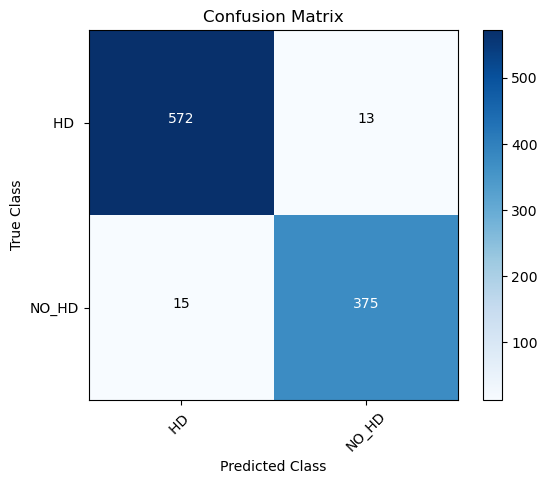

In [70]:
# GB Boost
X = df_upsampled.drop(["HD"],axis=1)
Y = df_upsampled["HD"]
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)
Model3 = GradientBoostingClassifier(random_state=45, learning_rate =0.1,n_estimators=10000,max_depth=10)
Model3.fit(X_train,y_train)
y_pred = Model3.predict(X_test)
fpr_Model3, tpr_Model3, thresholds_Model3 = roc_curve(y_test, y_pred)
roc_auc_Model3 = auc (fpr_Model3, tpr_Model3)
precision_Model3, recall_Model3, th_Model3 = precision_recall_curve(y_test, y_pred)
print(classification_report(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
#plot_confusion_matrix(Model3,X_test,y_test,display_labels=["LD","Non-LD"],cmap=plt.cm.Blues)
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add labels to the plot
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

In [71]:
#Features Importance Bar Plot
featur_names = ['SX', 'AG', 'SM', 'CPD', 'BPM', 'PS', 'PH', 'DB', 'TC', 'SBP', 'DBP',
       'BMI', 'HR', 'GL', 'HD']
features =Model3.feature_importances_
features

array([0.01748119, 0.16583294, 0.00298809, 0.06883262, 0.00324678,
       0.00143607, 0.01241518, 0.00351573, 0.12886341, 0.13713359,
       0.11260079, 0.13555305, 0.09598231, 0.11411825])

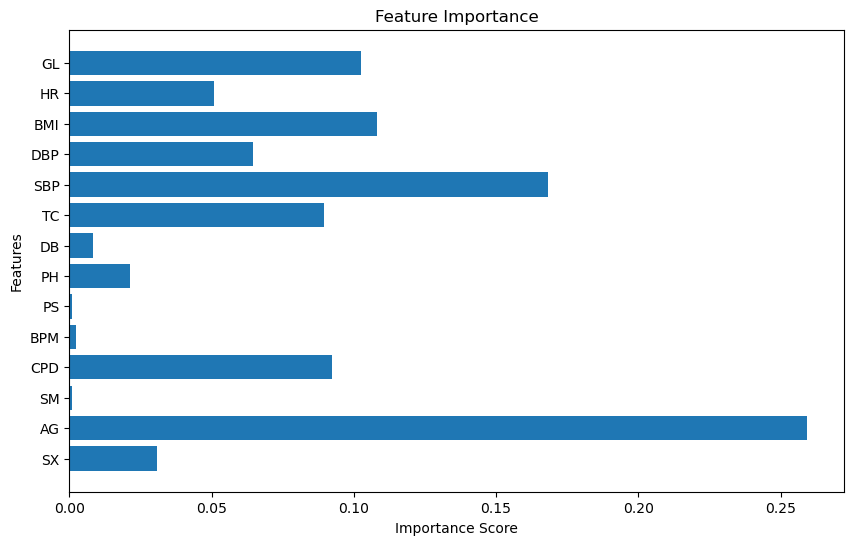

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor()
gbr.fit(X_train, y_train)

# Get the feature importance scores
importance_scores = gbr.feature_importances_
feature_names = X_train.columns

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_scores)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

# XAI

In [74]:
import shap
shap.initjs()

## SHAP

In [75]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(Model3.predict, X_train)
shap_values = explainer(X_test)

PermutationExplainer explainer: 976it [1:24:02,  5.17s/it]                                                             


In [76]:
np.shape(shap_values.values)

(975, 14)

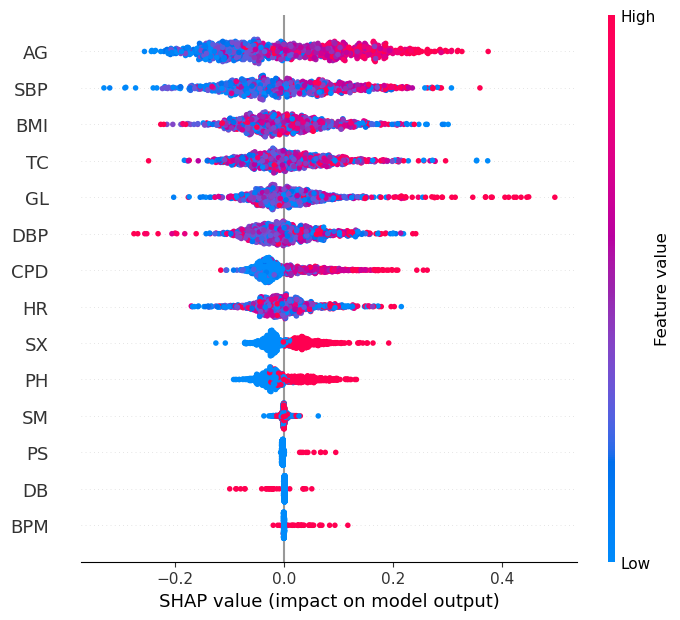

In [164]:
shap.plots.beeswarm(shap_values, max_display=len(shap_values.feature_names))

In [178]:
shap.plots.force(shap_values[110])

In [166]:
shap.plots.force(shap_values[0:100])

## LIME

In [179]:
#!pip install lime

import lime
import lime.lime_tabular

In [180]:
# Create a LimeTabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X.values,  # Use the NumPy array representation of X
    feature_names=X.columns.tolist(), # Feature names for interpretability
    class_names=['HD','NO_HD'], # Class names
    mode='classification' # or 'regression' depending on the task
)

In [185]:
# Choose an instance to explain
instance_index = 16 # Example: explain the first instance
instance = X.iloc[instance_index]

In [186]:
# Explain the instance
explanation = explainer.explain_instance(
    instance.values,
    lambda x: Model3.predict_proba(pd.DataFrame(x, columns=X.columns)), # Use a lambda function to wrap the prediction
    num_features=14  # Number of features to show in explanation
)

In [187]:
# Show the explanation
explanation.show_in_notebook(show_table=True)

In [188]:
explanation.as_list()

[('CPD > 20.00', 0.04228365565530967),
 ('AG <= 44.00', -0.03595980742881468),
 ('SBP <= 119.00', -0.02863960019768765),
 ('DBP <= 76.00', 0.02713051895189468),
 ('PS <= 0.00', -0.022602572742162198),
 ('SX <= 0.00', -0.01559387866023726),
 ('PH <= 0.00', -0.013571358961969645),
 ('80.00 < GL <= 87.00', -0.011811225699279886),
 ('DB <= 0.00', -0.009410707430434765),
 ('BMI <= 23.28', 0.00925540073815589),
 ('TC <= 210.00', 0.0071590586404200384),
 ('BPM <= 0.00', -0.006886309862632443),
 ('68.00 < HR <= 75.00', 0.002990582038765557),
 ('0.00 < SM <= 1.00', 0.0015194258789561694)]